In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_excel('final_dataset.xlsx')

In [5]:
df = df[:550]

In [6]:
display(df.head(10))

,Article #,Title,URL,Opening,Annotated Sentiment,Annotated Topic
0,1,Trump told McDonalds franchisees theyre luc...,https://www.ms.now/opinion/msnbc-opinion/trump...,Im honored to stand before you as the very fir...,positive,Administration
1,2,Senate suddenly passes the Epstein bill just h...,https://www.ms.now/news/senate-passes-epstein-...,Hours after the House overwhelmingly passed a ...,neutral,Legal Issues
2,3,Trump's praise for McDonald's Filet-O-Fish spa...,https://www.foxnews.com/food-drink/trumps-prai...,President Donald Trump has put one of McDonald...,positive,Administration
3,4,House demands Epstein financial records from J...,https://www.politico.com/live-updates/2025/11/...,Republicans are pushing ahead with an investig...,negative,Legal Issues
4,5,Trump dismisses Khashoggi's death while hostin...,https://www.upi.com/Top_News/US/2025/11/18/Tru...,President Donald Trump dismissed a reporter's ...,neutral,Foreign Relations
5,6,Appeals court rejects Trump's lawsuit against ...,https://www.upi.com/Top_News/US/2025/11/18/tru...,President Donald Trump's lawsuit against CNN f...,neutral,Legal Issues
6,7,Judge tosses DOJ suit against N.Y. for courtho...,https://www.upi.com/Top_News/US/2025/11/18/jud...,A federal judge dismissed a lawsuit Tuesday br...,negative,Immigration Policy
7,8,Trump hasnt lost Hispanic voters yet  but wa...,https://nypost.com/2025/11/18/opinion/trump-ha...,Is President Donald Trump losing the winning c...,negative,Electoral Politics
8,9,Gavin Newsom Destroys Trump With Embarrassing ...,https://radaronline.com/p/gavin-newsom-trolls-...,The feud between Gavin Newsom and Donald Trump...,negative,Administration
9,10,Trumps Scheme to Gift the GOP Extra House Sea...,https://slate.com/news-and-politics/2025/11/tr...,Sign up for the Slatest to get the most insigh...,positive,Administration


In [7]:
topics_n = df['Annotated Topic'].value_counts()
print(topics_n)

Annotated Topic
Administration        257
Foreign Relations      94
Legal Issues           63
Economic               51
Electoral Politics     33
Immigration Policy     24
Name: count, dtype: int64


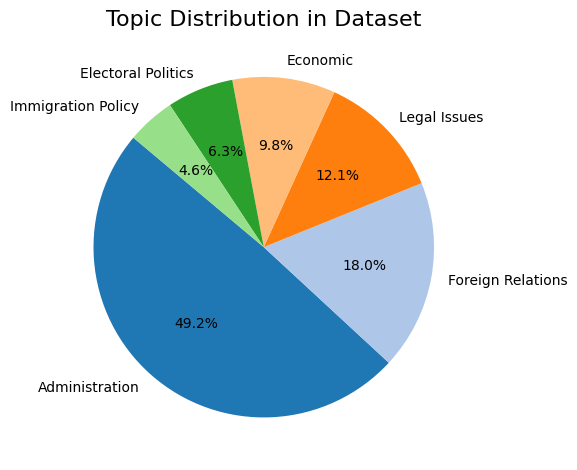

In [8]:
colors = plt.cm.tab20(range(len(topics_n)))   # pastel harmonious colors

plt.pie(
    topics_n,
    labels=topics_n.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors
)

plt.title('Topic Distribution in Dataset', fontsize=16)
plt.tight_layout()
plt.savefig("topics_dist.png", dpi=300)
plt.show()

In [9]:
counts = df.groupby(["Annotated Topic", "Annotated Sentiment"]).size().unstack(fill_value=0)
counts = counts[["positive", "neutral", "negative"]]


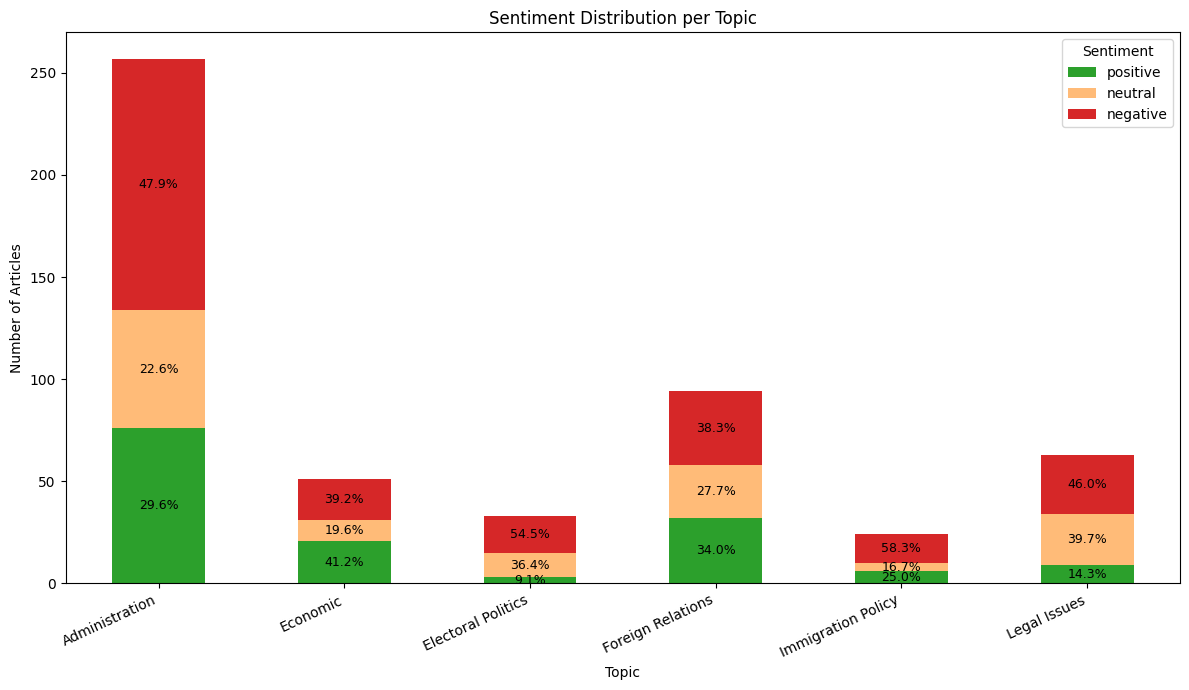

In [10]:
tab20 = plt.cm.tab20.colors

 

colors = [tab20[4], tab20[3], tab20[6]] #grey 14,16

ax = counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7),
    color=colors
)


totals = counts.sum(axis=1)
percentages = counts.div(totals, axis=0) * 100 
for i, topic in enumerate(counts.index):
    cum_height = 0
    for sentiment in counts.columns:
        height = counts.loc[topic, sentiment]
        if height == 0:
            continue
        pct = percentages.loc[topic, sentiment]
        ax.text(
            i,
            cum_height + height / 2,
            f"{pct:.1f}%",
            ha="center",
            va="center",
            fontsize=9
        )
        cum_height += height

plt.title("Sentiment Distribution per Topic")
plt.xlabel("Topic")
plt.ylabel("Number of Articles")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.savefig("sentiment_dist.png", dpi=300)
plt.show()

In [11]:
df = pd.read_csv("tfidf_top10.csv")

In [13]:
top_n = 5

# Get top N words per topic based on tf_idf
top_words = (
    df.sort_values(["Annotated Topic", "tf_idf"], ascending=[True, False])
      .groupby("Annotated Topic")
      .head(top_n)
)

topics = top_words["Annotated Topic"].unique()
n_topics = len(topics)

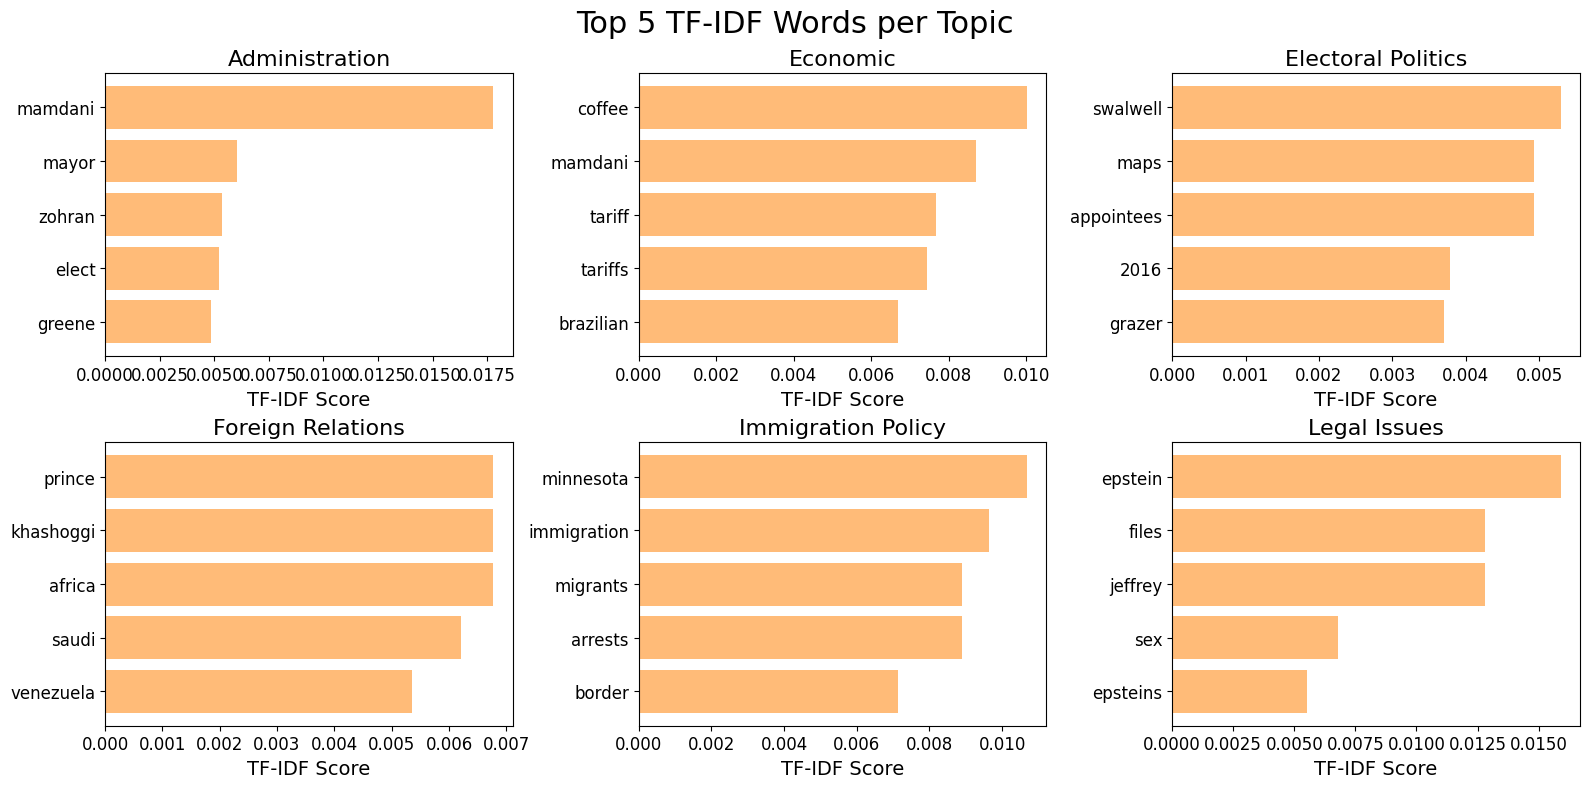

In [15]:
color = tab20[3]
cols = 3
rows = 2

plt.figure(figsize=(16, 8))

for i, topic in enumerate(topics):
    c = plt.subplot(rows, cols, i + 1)
    
    subset = top_words[top_words["Annotated Topic"] == topic]
    subset = subset.sort_values("tf_idf", ascending=True)

    c.barh(
        subset["word"],
        subset["tf_idf"],
        color=color
    )

    c.set_title(topic, fontsize=16)
    c.set_xlabel("TF-IDF Score", fontsize=14)
    c.tick_params(axis="y", labelsize=12)
    c.tick_params(axis="x", labelsize=12)

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.suptitle("Top 5 TF-IDF Words per Topic", fontsize=22)
plt.savefig("top5_tfidf_big.png", dpi=300)
plt.show()